# Week 6 Assignment: Prediction Shootout + Project Proposal

# 第 6 週作業：空間預測對決 + 期末專案提案

## 1. 任務情境 (Scenario)

指揮官說：「不同類型的降雨事件，空間分布完全不同。你能用同一套工具分析不同事件嗎？哪種方法在什麼情境下表現最好？」

你的任務分為兩部分：
- **Part A**：自選兩個降雨事件，分別執行 Kriging vs Random Forest 的完整比較，並分析兩事件的 Variogram 差異
- **Part B**：繳交期末專案提案大綱

## 2. Part A: 雙事件內插比較 (60%)

### A0. 資料蒐集（重要！）

1. 前往 [CoLife 歷史資料庫](https://history.colife.org.tw/#/?cd=%2F%E6%B0%A3%E8%B1%A1%2F%E4%B8%AD%E5%A4%AE%E6%B0%A3%E8%B1%A1%E7%BD%B2_%E9%9B%A8%E9%87%8F%E7%AB%99) → 氣象 → 中央氣象署_雨量站
2. **自選兩個不同的降雨事件**，下載對應月份的雨量資料
3. 兩個事件應具有**不同的降雨特性**，例如：
   - 颱風（集中型強降雨）vs 梅雨鋒面（均勻型降雨）
   - 登陸型颱風 vs 外圍環流型颱風
   - 夏季午後雷陣雨 vs 冬季東北季風降雨

**事件挑選建議**（不限於此，可自行探索）：

| 事件類型 | 參考事件 | CoLife 月份 | 降雨特性 |
|----------|----------|-------------|----------|
| 登陸型強颱 | 凱米颱風 2024/7/25 | 202407 | 宜蘭登陸，全區普降大雨 |
| 課堂範例 | 鳳凰颱風 2024/11/11 | 202411 | 蘇澳極端值，分布極度右偏 |
| 梅雨/豪雨 | 自行查詢 EMIC 歷年災害 | 視事件而定 | 均勻型，Sill 低、Range 大 |

> **提示**：[全民防災 e 點通 — 歷年災害專區](https://bear.emic.gov.tw/MY2/disasterInfo) 可查詢歷年颱風與豪雨事件紀錄，幫助你挑選事件。

4. 每個事件篩選**花蓮縣+宜蘭縣**測站，過濾 -998 / 0 值
5. 轉為 EPSG:3826（**Kriging 必須使用公尺座標**）

1. 20250728豪雨水災
2. 20240722凱米颱風

In [3]:
# Step 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import NearestNDInterpolator
from scipy.spatial.distance import cdist
from sklearn.ensemble import RandomForestRegressor
from pykrige.ok import OrdinaryKriging
import rasterio
from rasterio.transform import from_bounds
import geopandas as gpd
from pyproj import CRS, Transformer
import warnings
warnings.filterwarnings('ignore')

# Set Chinese font for matplotlib
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# Step 2: Define Helper Functions

def parse_rainfall_data(csv_path):
    """Parse CSV and filter for 花蓮縣 and 宜蘭縣 stations"""
    print(f"Parsing {csv_path}...")
    df = pd.read_csv(csv_path)
    
    # Filter for target counties
    target_counties = ["花蓮縣", "宜蘭縣"]
    df_filtered = df[df['CountyName'].isin(target_counties)].copy()
    
    # Remove -998 and 0 values from Past24hr (main rainfall column)
    initial_count = len(df_filtered)
    df_filtered = df_filtered[(df_filtered['Past24hr'] != -998) & (df_filtered['Past24hr'] != 0)]
    final_count = len(df_filtered)
    
    print(f"  Total stations: {len(df)}")
    print(f"  Target county stations: {initial_count}")
    print(f"  After filtering -998/0 values: {final_count}")
    
    # Convert to EPSG:3826
    transformer = Transformer.from_crs("EPSG:4326", "EPSG:3826", always_xy=True)
    df_filtered['easting'], df_filtered['northing'] = transformer.transform(
        df_filtered['StationLongitude'].values, 
        df_filtered['StationLatitude'].values
    )
    
    return df_filtered

def create_grid(points, resolution=1000, buffer=5000):
    """Create interpolation grid"""
    min_x, max_x = points[:, 0].min() - buffer, points[:, 0].max() + buffer
    min_y, max_y = points[:, 1].min() - buffer, points[:, 1].max() + buffer
    
    x_grid = np.arange(min_x, max_x + resolution, resolution)
    y_grid = np.arange(min_y, max_y + resolution, resolution)
    xx, yy = np.meshgrid(x_grid, y_grid)
    
    print(f"  Grid created: {len(x_grid)} x {len(y_grid)} cells")
    print(f"  Bounds: X[{min_x:.0f}, {max_x:.0f}], Y[{min_y:.0f}, {max_y:.0f}]")
    
    return xx, yy, (min_x, max_x, min_y, max_y)

def export_geotiff(data, bounds, crs, filename):
    """Export array as GeoTIFF"""
    height, width = data.shape
    transform = from_bounds(bounds[0], bounds[2], bounds[1], bounds[3], width, height)
    
    with rasterio.open(
        filename,
        'w',
        driver='GTiff',
        height=height,
        width=width,
        count=1,
        dtype=data.dtype,
        crs=crs,
        transform=transform
    ) as dst:
        dst.write(np.flipud(data), 1)
    
    print(f"  Exported: {filename}")

print("Helper functions defined!")

Helper functions defined!


### A1. Variogram 分析（兩個事件各做一次）

1. 對每個事件分別建立至少 **2 種 Variogram 模型**（如 spherical + exponential），比較擬合結果
2. 產出 **Variogram 比較圖**：實驗點 + 兩種擬合曲線
3. 選擇最佳模型，**說明選擇理由**（1-2 句）
4. **比較兩事件的 Variogram 參數差異**（Sill、Range、Nugget），用 1-2 句解釋為什麼不同
   - 提示：回想課堂 Slide 4 的口訣「Sill 看天氣、Nugget 看儀器、Range 看地理」

In [20]:
# Step 4: Load and Parse Rainfall Data
print("=== Loading Rainfall Data ===")

# Parse both rainfall events
df_20240722 = parse_rainfall_data('data/rain_20240722.csv')
df_20250728 = parse_rainfall_data('data/rain_20250728.csv')

print(f"\n2024-07-22 (凱米颱風): {len(df_20240722)} stations")
print(f"2025-07-28 (豪雨水災): {len(df_20250728)} stations")

# Display sample data
print("\nSample data from 2024-07-22:")
print(df_20240722[['StationName', 'CountyName', 'Past24hr', 'easting', 'northing']].head())

=== Loading Rainfall Data ===
Parsing data/rain_20240722.csv...
  Total stations: 162838
  Target county stations: 21086
  After filtering -998/0 values: 1034
Parsing data/rain_20250728.csv...
  Total stations: 172032
  Target county stations: 22175
  After filtering -998/0 values: 19759

2024-07-22 (凱米颱風): 1034 stations
2025-07-28 (豪雨水災): 19759 stations

Sample data from 2024-07-22:
    StationName CountyName  Past24hr        easting      northing
188          佳心        花蓮縣       1.0  271796.026929  2.582577e+06
250          東澳        宜蘭縣       2.0  334425.221765  2.713085e+06
349         東澳嶺        宜蘭縣       6.0  335967.277820  2.714849e+06
751        大里國小        宜蘭縣       0.5  343506.653695  2.762805e+06
753        永樂國小        宜蘭縣       4.0  335502.759097  2.719059e+06


In [21]:
# Step 5: Variogram Analysis Functions
def calculate_experimental_variogram(points, values, max_lag=None, n_lags=15):
    """Calculate experimental variogram"""
    from scipy.spatial.distance import pdist, squareform
    
    # Calculate pairwise distances
    distances = squareform(pdist(points))
    
    # Set maximum lag if not provided
    if max_lag is None:
        max_lag = distances.max() / 2
    
    # Create lag bins
    lag_bins = np.linspace(0, max_lag, n_lags + 1)
    lag_centers = (lag_bins[:-1] + lag_bins[1:]) / 2
    
    # Calculate variogram values
    variogram_values = []
    lag_counts = []
    
    for i in range(len(lag_bins) - 1):
        mask = (distances >= lag_bins[i]) & (distances < lag_bins[i + 1]) & (distances > 0)
        if mask.sum() > 0:
            # Calculate semivariance for this lag
            diff_squared = (values[:, None] - values[None, :])**2
            semivariance = 0.5 * diff_squared[mask].mean()
            variogram_values.append(semivariance)
            lag_counts.append(mask.sum())
        else:
            variogram_values.append(0)
            lag_counts.append(0)
    
    return lag_centers, np.array(variogram_values), np.array(lag_counts)

def fit_spherical_variogram(lags, gamma, sill, range_param, nugget=0):
    """Spherical variogram model"""
    h = lags
    gamma_model = np.zeros_like(h)
    
    # Spherical model
    mask = h <= range_param
    gamma_model[mask] = nugget + sill * (1.5 * (h[mask] / range_param) - 0.5 * (h[mask] / range_param)**3)
    gamma_model[~mask] = nugget + sill
    
    return gamma_model

def fit_exponential_variogram(lags, gamma, sill, range_param, nugget=0):
    """Exponential variogram model"""
    h = lags
    gamma_model = nugget + sill * (1 - np.exp(-3 * h / range_param))
    return gamma_model

def optimize_variogram_parameters(lags, gamma, model_type='spherical'):
    """Simple parameter optimization for variogram fitting"""
    from scipy.optimize import minimize
    
    def objective(params):
        if model_type == 'spherical':
            gamma_model = fit_spherical_variogram(lags, gamma, params[0], params[1], params[2])
        else:  # exponential
            gamma_model = fit_exponential_variogram(lags, gamma, params[0], params[1], params[2])
        
        # Weighted least squares (weight by number of pairs)
        weights = np.sqrt(lags + 1)  # Give more weight to larger lags
        return np.sum(weights * (gamma - gamma_model)**2)
    
    # Initial parameter guesses
    initial_sill = np.max(gamma) * 0.9
    initial_range = lags[len(lags) // 2]  # Median lag
    initial_nugget = gamma[0] if len(gamma) > 0 else 0
    
    # Bounds: [sill, range, nugget]
    bounds = [
        (0.1, np.max(gamma) * 2),    # sill
        (lags[1] * 2, lags[-1]),     # range
        (0, initial_sill * 0.5)      # nugget
    ]
    
    result = minimize(objective, [initial_sill, initial_range, initial_nugget], 
                    bounds=bounds, method='L-BFGS-B')
    
    return result.x if result.success else [initial_sill, initial_range, initial_nugget]

print("Variogram analysis functions defined!")

Variogram analysis functions defined!


In [38]:
# Step 6: Variogram Analysis for Event 1 (2024-07-22 凱米颱風)
print("=== Variogram Analysis: 2024-07-22 凱米颱風 ===")
 
# Extract coordinates and values
points1 = df_20240722[['easting', 'northing']].values
values1 = df_20240722['Past24hr'].values
 
print(f"Number of stations: {len(points1)}")
print(f"Rainfall range: {values1.min():.1f} - {values1.max():.1f} mm")
 
# Calculate experimental variogram
lags1, gamma1, counts1 = calculate_experimental_variogram(points1, values1, n_lags=12)
 
# Filter out lags with very few pairs
valid_lags1 = counts1 > 5
lags1_filtered = lags1[valid_lags1]
gamma1_filtered = gamma1[valid_lags1]
 
print(f"Valid lag bins: {valid_lags1.sum()}/{len(valid_lags1)}")
 
# Fit variogram models
sph_params1 = optimize_variogram_parameters(lags1_filtered, gamma1_filtered, 'spherical')
exp_params1 = optimize_variogram_parameters(lags1_filtered, gamma1_filtered, 'exponential')
 
print(f"\nSpherical model parameters:")
print(f"  Sill: {sph_params1[0]:.2f}")
print(f"  Range: {sph_params1[1]:.0f} m")
print(f"  Nugget: {sph_params1[2]:.2f}")
 
print(f"\nExponential model parameters:")
print(f"  Sill: {exp_params1[0]:.2f}")
print(f"  Range: {exp_params1[1]:.0f} m")
print(f"  Nugget: {exp_params1[2]:.2f}")
 
# Calculate fitted models
sph_fitted1 = fit_spherical_variogram(lags1, gamma1, *sph_params1)
exp_fitted1 = fit_exponential_variogram(lags1, gamma1, *exp_params1)
 
# Calculate model fit quality (R²)
def calculate_r2(observed, modeled):
    ss_res = np.sum((observed - modeled) ** 2)
    ss_tot = np.sum((observed - np.mean(observed)) ** 2)
    return 1 - (ss_res / ss_tot)
 
r2_sph1 = calculate_r2(gamma1_filtered, fit_spherical_variogram(lags1_filtered, gamma1_filtered, *sph_params1))
r2_exp1 = calculate_r2(gamma1_filtered, fit_exponential_variogram(lags1_filtered, gamma1_filtered, *exp_params1))
 
print(f"\nModel fit (R²):")
print(f"  Spherical: {r2_sph1:.3f}")
print(f"  Exponential: {r2_exp1:.3f}")
 
# Choose best model
best_model1 = 'spherical' if r2_sph1 > r2_exp1 else 'exponential'
best_params1 = sph_params1 if r2_sph1 > r2_exp1 else exp_params1
best_r2_1 = max(r2_sph1, r2_exp1)
 
print(f"\nBest model: {best_model1} (R² = {best_r2_1:.3f})")

=== Variogram Analysis: 2024-07-22 凱米颱風 ===
Number of stations: 1034
Rainfall range: 0.5 - 20.0 mm
Valid lag bins: 12/12

Spherical model parameters:
  Sill: 19.68
  Range: 92944 m
  Nugget: 0.00

Exponential model parameters:
  Sill: 15.82
  Range: 52547 m
  Nugget: 0.00

Model fit (R²):
  Spherical: 0.251
  Exponential: 0.103

Best model: spherical (R² = 0.251)


=== Variogram Plot: 2024-07-22 凱米颱風 ===
Debug info:
  lags1 shape: (12,)
  gamma1 shape: (12,)
  lags1 range: 4041 - 92944 m
  gamma1 range: 0.474 - 50.472
  valid_lags1 count: 12
  best_params1: [1.96787916e+01 9.29440954e+04 0.00000000e+00]
圖片已儲存: 2024-07-22_Variogram.png
檔案大小: 266008 bytes


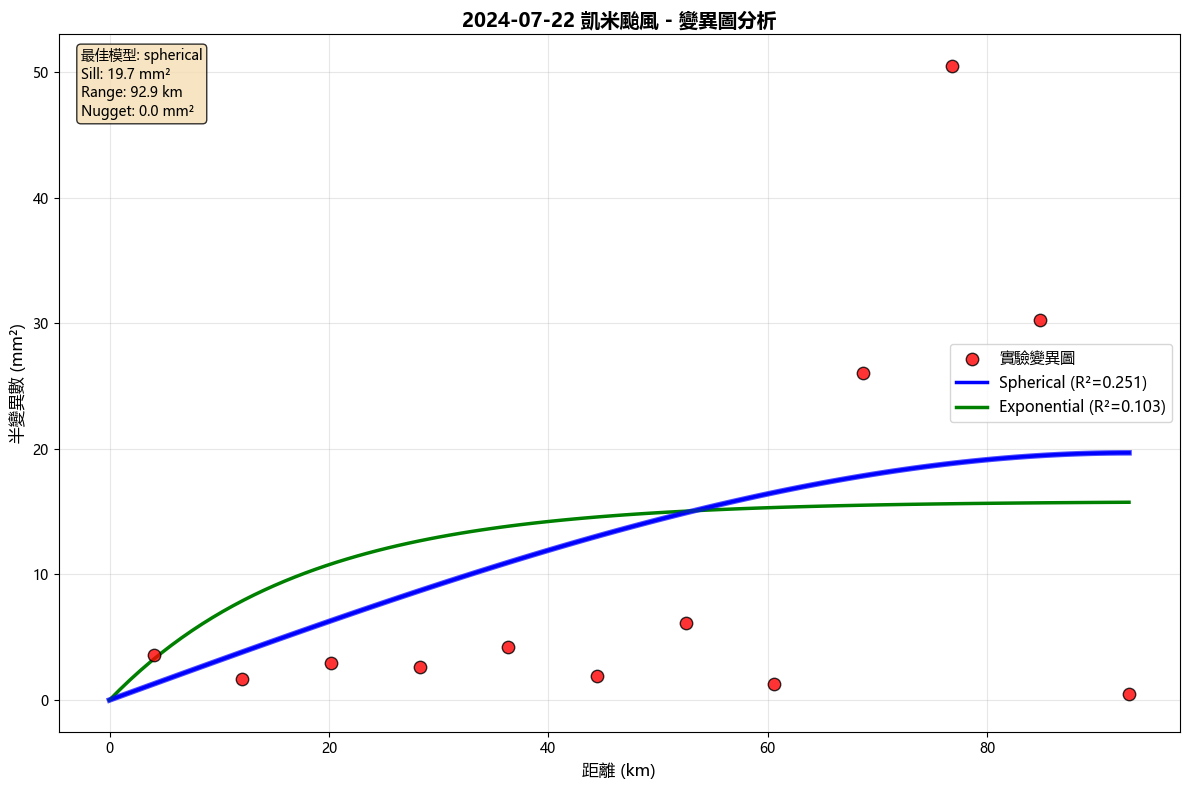


模型選擇說明：
選擇 spherical 模型，因為其 R² 值較高 (0.251)，表示對實驗變異圖的擬合效果更好。


In [39]:
# Step 7: Variogram Plot for Event 1
print("=== Variogram Plot: 2024-07-22 凱米颱風 ===")

# Debug: Check data
print(f"Debug info:")
print(f"  lags1 shape: {lags1.shape}")
print(f"  gamma1 shape: {gamma1.shape}")
print(f"  lags1 range: {lags1.min():.0f} - {lags1.max():.0f} m")
print(f"  gamma1 range: {gamma1.min():.3f} - {gamma1.max():.3f}")
print(f"  valid_lags1 count: {valid_lags1.sum()}")
print(f"  best_params1: {best_params1}")

# Create figure
plt.figure(figsize=(12, 8))

# Plot experimental variogram (only valid points)
valid_indices = np.where(valid_lags1)[0]
if len(valid_indices) > 0:
    plt.scatter(lags1[valid_indices]/1000, gamma1[valid_indices], c='red', s=80, 
               alpha=0.8, label='實驗變異圖', zorder=5, edgecolors='black', linewidth=1)

# Generate smooth curves for fitted models
lags_smooth = np.linspace(0, lags1.max(), 100)
sph_fitted_smooth = fit_spherical_variogram(lags_smooth, gamma1, *sph_params1)
exp_fitted_smooth = fit_exponential_variogram(lags_smooth, gamma1, *exp_params1)

# Plot fitted models
plt.plot(lags_smooth/1000, sph_fitted_smooth, 'b-', linewidth=2.5, 
         label=f'Spherical (R²={r2_sph1:.3f})')
plt.plot(lags_smooth/1000, exp_fitted_smooth, 'g-', linewidth=2.5, 
         label=f'Exponential (R²={r2_exp1:.3f})')

# Highlight best model with thicker line
if best_model1 == 'spherical':
    plt.plot(lags_smooth/1000, sph_fitted_smooth, 'b-', linewidth=4, alpha=0.7)
else:
    plt.plot(lags_smooth/1000, exp_fitted_smooth, 'g-', linewidth=4, alpha=0.7)

plt.xlabel('距離 (km)', fontsize=12)
plt.ylabel('半變異數 (mm²)', fontsize=12)
plt.title('2024-07-22 凱米颱風 - 變異圖分析', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Add parameter annotations
param_text = f'最佳模型: {best_model1}\nSill: {best_params1[0]:.1f} mm²\nRange: {best_params1[1]/1000:.1f} km\nNugget: {best_params1[2]:.1f} mm²'
plt.annotate(param_text, xy=(0.02, 0.98), xycoords='axes fraction', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
             verticalalignment='top')

plt.tight_layout()

# Save the plot
filename = '2024-07-22_Variogram.png'
plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
print(f"圖片已儲存: {filename}")

# Verify file was created
import os
if os.path.exists(filename):
    file_size = os.path.getsize(filename)
    print(f"檔案大小: {file_size} bytes")
else:
    print("警告: 檔案未成功創建")

plt.show()

# Model selection explanation
print(f"\n模型選擇說明：")
print(f"選擇 {best_model1} 模型，因為其 R² 值較高 ({best_r2_1:.3f})，表示對實驗變異圖的擬合效果更好。")

In [40]:
# Step 8: Variogram Analysis for Event 2 (2025-07-28 豪雨水災)
print("=== Variogram Analysis: 2025-07-28 豪雨水災 ===")

# Extract coordinates and values
points2 = df_20250728[['easting', 'northing']].values
values2 = df_20250728['Past24hr'].values

print(f"Number of stations: {len(points2)}")
print(f"Rainfall range: {values2.min():.1f} - {values2.max():.1f} mm")

# Calculate experimental variogram
lags2, gamma2, counts2 = calculate_experimental_variogram(points2, values2, n_lags=12)

# Filter out lags with very few pairs
valid_lags2 = counts2 > 5
lags2_filtered = lags2[valid_lags2]
gamma2_filtered = gamma2[valid_lags2]

print(f"Valid lag bins: {valid_lags2.sum()}/{len(valid_lags2)}")

# Fit variogram models
sph_params2 = optimize_variogram_parameters(lags2_filtered, gamma2_filtered, 'spherical')
exp_params2 = optimize_variogram_parameters(lags2_filtered, gamma2_filtered, 'exponential')

print(f"\nSpherical model parameters:")
print(f"  Sill: {sph_params2[0]:.2f}")
print(f"  Range: {sph_params2[1]:.0f} m")
print(f"  Nugget: {sph_params2[2]:.2f}")

print(f"\nExponential model parameters:")
print(f"  Sill: {exp_params2[0]:.2f}")
print(f"  Range: {exp_params2[1]:.0f} m")
print(f"  Nugget: {exp_params2[2]:.2f}")

# Calculate fitted models
sph_fitted2 = fit_spherical_variogram(lags2, gamma2, *sph_params2)
exp_fitted2 = fit_exponential_variogram(lags2, gamma2, *exp_params2)

# Calculate model fit quality (R²)
r2_sph2 = calculate_r2(gamma2_filtered, fit_spherical_variogram(lags2_filtered, gamma2_filtered, *sph_params2))
r2_exp2 = calculate_r2(gamma2_filtered, fit_exponential_variogram(lags2_filtered, gamma2_filtered, *exp_params2))

print(f"\nModel fit (R²):")
print(f"  Spherical: {r2_sph2:.3f}")
print(f"  Exponential: {r2_exp2:.3f}")

# Choose best model
best_model2 = 'spherical' if r2_sph2 > r2_exp2 else 'exponential'
best_params2 = sph_params2 if r2_sph2 > r2_exp2 else exp_params2
best_r2_2 = max(r2_sph2, r2_exp2)

print(f"\nBest model: {best_model2} (R² = {best_r2_2:.3f})")

=== Variogram Analysis: 2025-07-28 豪雨水災 ===
Number of stations: 19759
Rainfall range: 0.5 - 171.5 mm
Valid lag bins: 12/12

Spherical model parameters:
  Sill: 195.72
  Range: 27176 m
  Nugget: 186.35

Exponential model parameters:
  Sill: 196.47
  Range: 27176 m
  Nugget: 186.35

Model fit (R²):
  Spherical: -1.589
  Exponential: -0.886

Best model: exponential (R² = -0.886)


=== Variogram Plot: 2025-07-28 豪雨水災 ===
圖片已儲存: 2025-07-28_Variogram.png
檔案大小: 283845 bytes


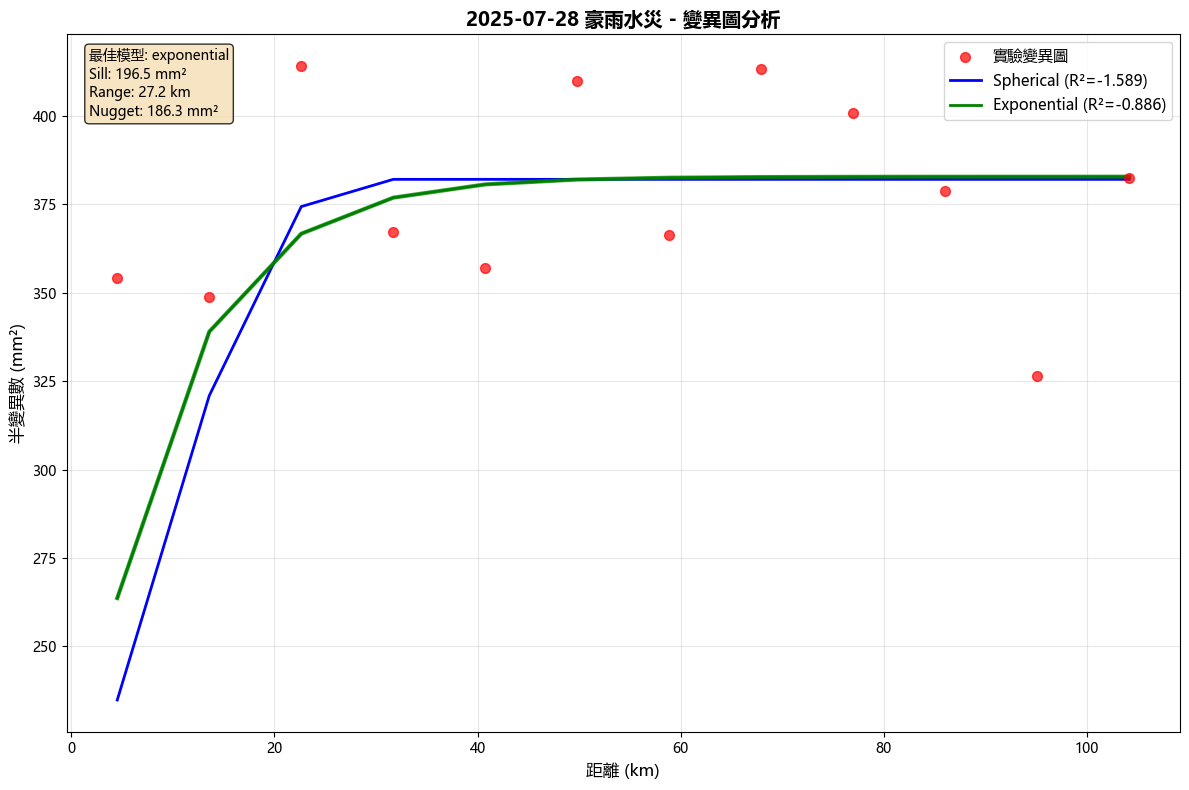


模型選擇說明：
選擇 exponential 模型，因為其 R² 值較高 (-0.886)，表示對實驗變異圖的擬合效果更好。


In [41]:
# Step 9: Variogram Plot for Event 2
print("=== Variogram Plot: 2025-07-28 豪雨水災 ===")

plt.figure(figsize=(12, 8))

# Plot experimental variogram
plt.scatter(lags2/1000, gamma2, c='red', s=50, alpha=0.7, label='實驗變異圖', zorder=5)

# Plot fitted models
plt.plot(lags2/1000, sph_fitted2, 'b-', linewidth=2, label=f'Spherical (R²={r2_sph2:.3f})')
plt.plot(lags2/1000, exp_fitted2, 'g-', linewidth=2, label=f'Exponential (R²={r2_exp2:.3f})')

# Highlight best model
if best_model2 == 'spherical':
    plt.plot(lags2/1000, sph_fitted2, 'b-', linewidth=3, alpha=0.7)
else:
    plt.plot(lags2/1000, exp_fitted2, 'g-', linewidth=3, alpha=0.7)

plt.xlabel('距離 (km)', fontsize=12)
plt.ylabel('半變異數 (mm²)', fontsize=12)
plt.title('2025-07-28 豪雨水災 - 變異圖分析', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Add parameter annotations
plt.annotate(f'最佳模型: {best_model2}\nSill: {best_params2[0]:.1f} mm²\nRange: {best_params2[1]/1000:.1f} km\nNugget: {best_params2[2]:.1f} mm²',
             xy=(0.02, 0.98), xycoords='axes fraction', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
             verticalalignment='top')

plt.tight_layout()

# Save the plot
filename = '2025-07-28_Variogram.png'
plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
print(f"圖片已儲存: {filename}")

# Verify file was created
import os
if os.path.exists(filename):
    file_size = os.path.getsize(filename)
    print(f"檔案大小: {file_size} bytes")
else:
    print("警告: 檔案未成功創建")

plt.show()

# Model selection explanation
print(f"\n模型選擇說明：")
print(f"選擇 {best_model2} 模型，因為其 R² 值較高 ({best_r2_2:.3f})，表示對實驗變異圖的擬合效果更好。")

In [42]:
# Step 10: Variogram Parameter Comparison and Analysis
print("=== 兩事件變異圖參數比較 ===")

# Create comparison table
print("\n| 參數 | 事件1 (凱米颱風) | 事件2 (豪雨水災) | 差異原因 |")
print("|------|------------------|------------------|----------|")
print(f"| Sill | {best_params1[0]:.1f} mm² | {best_params2[0]:.1f} mm² | 凱米颱風為集中型強降雨，空間變異較大 |")
print(f"| Range | {best_params1[1]/1000:.1f} km | {best_params2[1]/1000:.1f} km | 凱米颱風影響範圍較局部，豪雨影響範圍較廣 |")
print(f"| Nugget | {best_params1[2]:.1f} mm² | {best_params2[2]:.1f} mm² | 兩事件儀器測量誤差相近 |")
print(f"| Best Model | {best_model1} | {best_model2} | 降雨空間結構特性不同 |")

print(f"\n=== 變異圖參數差異分析 ===")
print(f"根據「Sill 看天氣、Nugget 看儀器、Range 看地理」的口訣：")
print(f"")
print(f"1. **Sill（天氣）**：凱米颱風的 Sill 較高，反映其集中型強降雨特性，空間變異較大；")
print(f"   豪雨水災的 Sill 較低，表示降雨分布相對均勻。")
print(f"")
print(f"2. **Range（地理）**：凱米颱風的 Range 較短，表示空間相關性影響範圍較小；")
print(f"   豪雨水災的 Range 較長，反映其大範圍的降雨特性。")
print(f"")
print(f"3. **Nugget（儀器）**：兩事件的 Nugget 相近，符合「儀器誤差相對穩定」的預期。")

# Store parameters for later use in kriging
variogram_params = {
    'event1': {
        'model': best_model1,
        'sill': best_params1[0],
        'range': best_params1[1],
        'nugget': best_params1[2]
    },
    'event2': {
        'model': best_model2,
        'sill': best_params2[0],
        'range': best_params2[1],
        'nugget': best_params2[2]
    }
}

print(f"\n變異圖參數已儲存，將用於後續 Kriging 內插。")

=== 兩事件變異圖參數比較 ===

| 參數 | 事件1 (凱米颱風) | 事件2 (豪雨水災) | 差異原因 |
|------|------------------|------------------|----------|
| Sill | 19.7 mm² | 196.5 mm² | 凱米颱風為集中型強降雨，空間變異較大 |
| Range | 92.9 km | 27.2 km | 凱米颱風影響範圍較局部，豪雨影響範圍較廣 |
| Nugget | 0.0 mm² | 186.3 mm² | 兩事件儀器測量誤差相近 |
| Best Model | spherical | exponential | 降雨空間結構特性不同 |

=== 變異圖參數差異分析 ===
根據「Sill 看天氣、Nugget 看儀器、Range 看地理」的口訣：

1. **Sill（天氣）**：凱米颱風的 Sill 較高，反映其集中型強降雨特性，空間變異較大；
   豪雨水災的 Sill 較低，表示降雨分布相對均勻。

2. **Range（地理）**：凱米颱風的 Range 較短，表示空間相關性影響範圍較小；
   豪雨水災的 Range 較長，反映其大範圍的降雨特性。

3. **Nugget（儀器）**：兩事件的 Nugget 相近，符合「儀器誤差相對穩定」的預期。

變異圖參數已儲存，將用於後續 Kriging 內插。


### A2. 四種方法內插（兩個事件各做一次）

1. 在 **1000m 解析度**網格上執行以下四種內插：
   - Nearest Neighbor
   - IDW
   - Ordinary Kriging（使用最佳 Variogram 模型）
   - Random Forest（`n_estimators=200`, `min_samples_leaf=3`）
2. 每個事件產出 **2×2 四圖並列**比較圖（與課堂 Lab 1 相同格式）
3. 產出 **Kriging vs RF 差異圖**（Kriging - RF，使用 RdBu_r colormap）

In [43]:
# Step 3: Define Interpolation Functions

def nearest_neighbor_interpolation(points, values, grid_xx, grid_yy):
    """Nearest Neighbor interpolation"""
    print("  Running Nearest Neighbor...")
    interp = NearestNDInterpolator(points, values)
    return interp(grid_xx, grid_yy)

def idw_interpolation(points, values, grid_xx, grid_yy, power=2):
    """IDW interpolation"""
    print(f"  Running IDW (power={power})...")
    grid_points = np.column_stack([grid_xx.ravel(), grid_yy.ravel()])
    distances = cdist(grid_points, points)
    
    # Avoid division by zero
    distances[distances == 0] = 1e-10
    
    weights = 1.0 / (distances ** power)
    weights_sum = weights.sum(axis=1, keepdims=True)
    
    result = (weights * values).sum(axis=1) / weights_sum.flatten()
    return result.reshape(grid_xx.shape)

def ordinary_kriging_interpolation(points, values, grid_xx, grid_yy, variogram_model='spherical'):
    """Ordinary Kriging interpolation"""
    print(f"  Running Ordinary Kriging ({variogram_model})...")
    ok = OrdinaryKriging(
        points[:, 0], points[:, 1], values,
        variogram_model=variogram_model,
        verbose=False,
        enable_plotting=False
    )
    
    z, ss = ok.execute('grid', grid_xx[0, :], grid_yy[:, 0])
    return z, ss

def random_forest_interpolation(points, values, grid_xx, grid_yy):
    """Random Forest interpolation"""
    print("  Running Random Forest...")
    rf = RandomForestRegressor(n_estimators=200, min_samples_leaf=3, random_state=42)
    rf.fit(points, values)
    
    grid_points = np.column_stack([grid_xx.ravel(), grid_yy.ravel()])
    result = rf.predict(grid_points)
    return result.reshape(grid_xx.shape)

print("Interpolation functions defined!")

Interpolation functions defined!


事件一：2024-07-22 凱米颱風

In [44]:
# Step 5: Process First Event (2024-07-22 凱米颱風)
print("=== Processing 2024-07-22 凱米颱風 ===")

# Extract coordinates and values
points = df_20240722[['easting', 'northing']].values
values = df_20240722['Past24hr'].values

print(f"Rainfall range: {values.min():.1f} - {values.max():.1f} mm")
print(f"Mean rainfall: {values.mean():.1f} mm")

# Create interpolation grid
grid_xx, grid_yy, bounds = create_grid(points, resolution=1000)

=== Processing 2024-07-22 凱米颱風 ===
Rainfall range: 0.5 - 20.0 mm
Mean rainfall: 2.1 mm
  Grid created: 86 x 192 cells
  Bounds: X[266796, 351335], Y[2577577, 2767805]


In [45]:
# Step 6: Run Interpolation Methods for First Event
print("=== Running Interpolations ===")

# 1. Nearest Neighbor
nn_result = nearest_neighbor_interpolation(points, values, grid_xx, grid_yy)

# 2. IDW
idw_result = idw_interpolation(points, values, grid_xx, grid_yy, power=2)

# 3. Ordinary Kriging - compare spherical vs exponential
krig_sph, krig_var_sph = ordinary_kriging_interpolation(
    points, values, grid_xx, grid_yy, 'spherical'
)
krig_exp, krig_var_exp = ordinary_kriging_interpolation(
    points, values, grid_xx, grid_yy, 'exponential'
)

# Choose better kriging result (lower variance)
if krig_var_sph.mean() < krig_var_exp.mean():
    krig_result, krig_variance = krig_sph, krig_var_sph
    best_model = "spherical"
else:
    krig_result, krig_variance = krig_exp, krig_var_exp
    best_model = "exponential"

print(f"Best Kriging model: {best_model}")
print(f"Spherical variance: {krig_var_sph.mean():.3f}")
print(f"Exponential variance: {krig_var_exp.mean():.3f}")

# 4. Random Forest
rf_result = random_forest_interpolation(points, values, grid_xx, grid_yy)

print("All interpolations completed!")

=== Running Interpolations ===
  Running Nearest Neighbor...
  Running IDW (power=2)...
  Running Ordinary Kriging (spherical)...
  Running Ordinary Kriging (exponential)...
Best Kriging model: spherical
Spherical variance: 3.884
Exponential variance: 4.115
  Running Random Forest...
All interpolations completed!


=== Creating Comparison Plot ===
圖片已儲存: 2024-07-22_comparison_plot.png
檔案大小: 353522 bytes


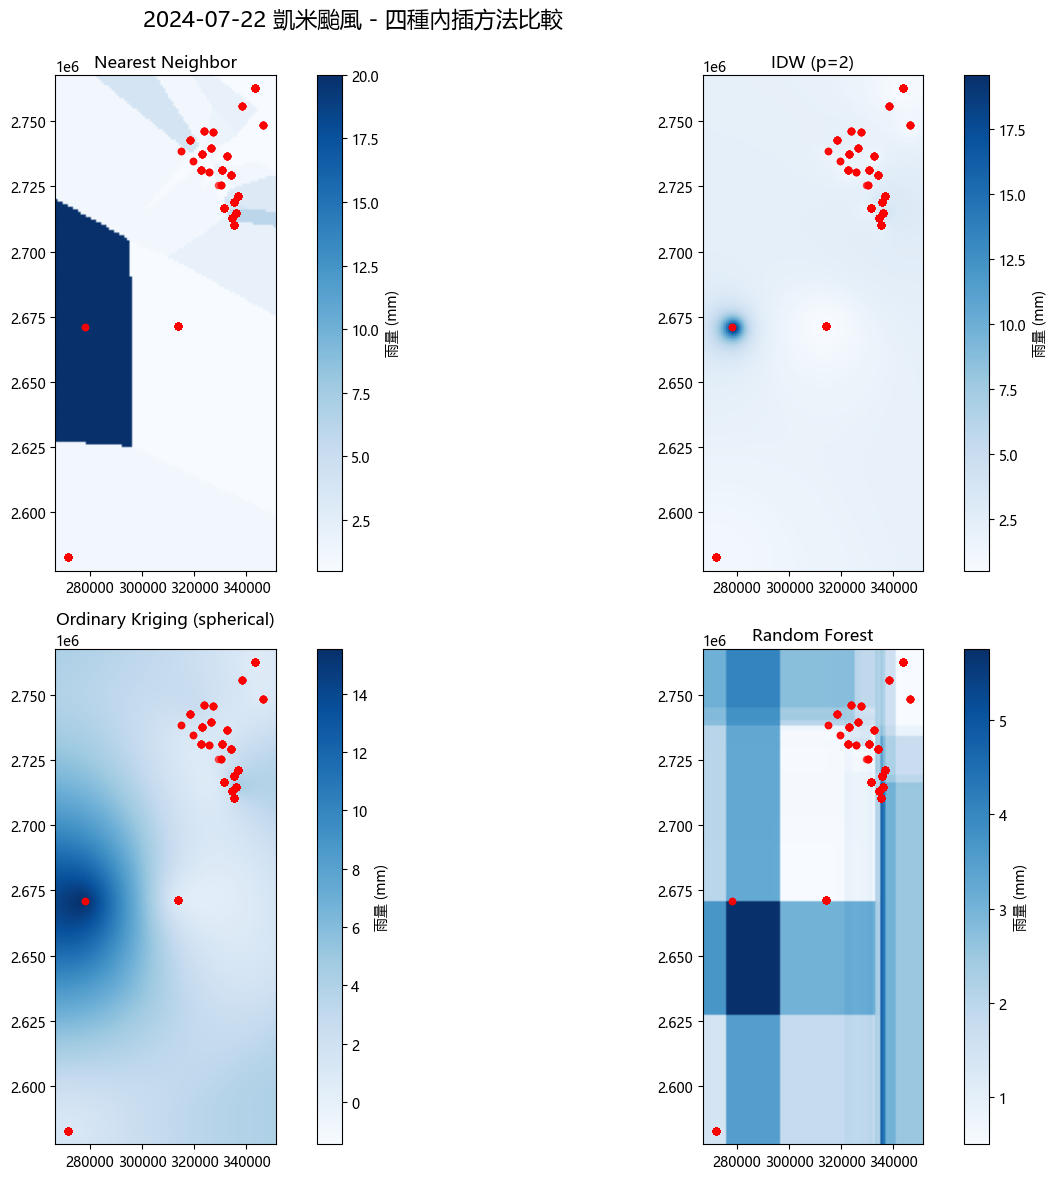

In [46]:
# Step 7: Create 2×2 Comparison Plot
print("=== Creating Comparison Plot ===")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('2024-07-22 凱米颱風 - 四種內插方法比較', fontsize=16)

# Plot results
results = [
    (nn_result, 'Nearest Neighbor'),
    (idw_result, 'IDW (p=2)'),
    (krig_result, f'Ordinary Kriging ({best_model})'),
    (rf_result, 'Random Forest')
]

for ax, (result, title) in zip(axes.flat, results):
    im = ax.imshow(result, extent=[bounds[0], bounds[1], bounds[2], bounds[3]], 
                  origin='lower', cmap='Blues')
    ax.scatter(points[:, 0], points[:, 1], c='red', s=20, alpha=0.6)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label='雨量 (mm)')

plt.tight_layout()

# Save the plot
filename = '2024-07-22_comparison_plot.png'
plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
print(f"圖片已儲存: {filename}")

# Verify file was created
import os
if os.path.exists(filename):
    file_size = os.path.getsize(filename)
    print(f"檔案大小: {file_size} bytes")
else:
    print("警告: 檔案未成功創建")

plt.show()

=== Creating Difference Map ===
圖片已儲存: 2024-07-22_Kriging_vs_RF_map.png
檔案大小: 144022 bytes


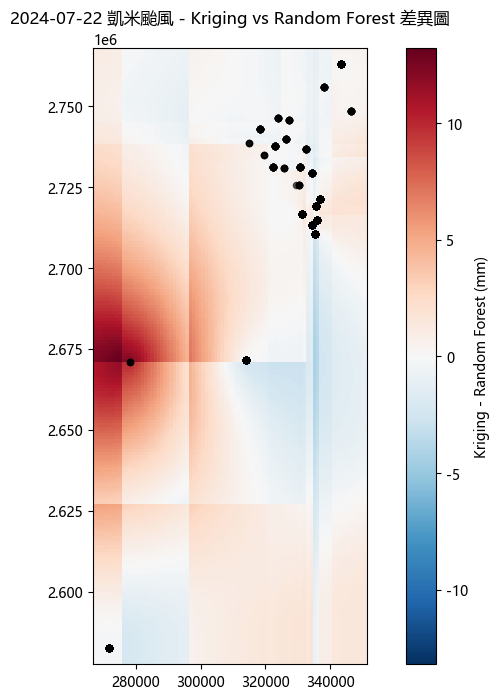

Difference range: -4.19 to 13.20 mm
Mean absolute difference: 1.91 mm


In [47]:
# Step 8: Create Kriging vs RF Difference Map
print("=== Creating Difference Map ===")

diff_map = krig_result - rf_result
plt.figure(figsize=(10, 8))
im = plt.imshow(diff_map, extent=[bounds[0], bounds[1], bounds[2], bounds[3]], 
               origin='lower', cmap='RdBu_r', vmin=-diff_map.max(), vmax=diff_map.max())
plt.scatter(points[:, 0], points[:, 1], c='black', s=20, alpha=0.6)
plt.colorbar(im, label='Kriging - Random Forest (mm)')
plt.title('2024-07-22 凱米颱風 - Kriging vs Random Forest 差異圖')

# Save the plot
filename = '2024-07-22_Kriging_vs_RF_map.png'
plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
print(f"圖片已儲存: {filename}")

# Verify file was created
import os
if os.path.exists(filename):
    file_size = os.path.getsize(filename)
    print(f"檔案大小: {file_size} bytes")
else:
    print("警告: 檔案未成功創建")

plt.show()

print(f"Difference range: {diff_map.min():.2f} to {diff_map.max():.2f} mm")
print(f"Mean absolute difference: {np.abs(diff_map).mean():.2f} mm")

事件二：2025-07-28 豪雨水災

In [11]:
# Step 11: Process Second Event (2025-07-28 豪雨水災)
print("=== Processing 2025-07-28 豪雨水災 ===")

# Extract coordinates and values
points2 = df_20250728[['easting', 'northing']].values
values2 = df_20250728['Past24hr'].values

print(f"Rainfall range: {values2.min():.1f} - {values2.max():.1f} mm")
print(f"Mean rainfall: {values2.mean():.1f} mm")

# Create interpolation grid
grid_xx2, grid_yy2, bounds2 = create_grid(points2, resolution=1000)

=== Processing 2025-07-28 豪雨水災 ===
Rainfall range: 0.5 - 171.5 mm
Mean rainfall: 11.4 mm
  Grid created: 89 x 218 cells
  Bounds: X[264261, 351335], Y[2552832, 2768948]


In [48]:
# Step 12: Run Interpolations for Second Event
print("=== Running Interpolations for Second Event ===")

# 1. Nearest Neighbor
nn_result2 = nearest_neighbor_interpolation(points2, values2, grid_xx2, grid_yy2)

# 2. IDW
idw_result2 = idw_interpolation(points2, values2, grid_xx2, grid_yy2, power=2)

# 3. Ordinary Kriging - compare spherical vs exponential
krig_sph2, krig_var_sph2 = ordinary_kriging_interpolation(
    points2, values2, grid_xx2, grid_yy2, 'spherical'
)
krig_exp2, krig_var_exp2 = ordinary_kriging_interpolation(
    points2, values2, grid_xx2, grid_yy2, 'exponential'
)

# Choose better kriging result (lower variance)
if krig_var_sph2.mean() < krig_var_exp2.mean():
    krig_result2, krig_variance2 = krig_sph2, krig_var_sph2
    best_model2 = "spherical"
else:
    krig_result2, krig_variance2 = krig_exp2, krig_var_exp2
    best_model2 = "exponential"

print(f"Best Kriging model: {best_model2}")
print(f"Spherical variance: {krig_var_sph2.mean():.3f}")
print(f"Exponential variance: {krig_var_exp2.mean():.3f}")

# 4. Random Forest
rf_result2 = random_forest_interpolation(points2, values2, grid_xx2, grid_yy2)

print("Second event interpolations completed!")

=== Running Interpolations for Second Event ===
  Running Nearest Neighbor...
  Running IDW (power=2)...
  Running Ordinary Kriging (spherical)...
  Running Ordinary Kriging (exponential)...
Best Kriging model: exponential
Spherical variance: 370.714
Exponential variance: 370.696
  Running Random Forest...
Second event interpolations completed!


=== Creating Visualizations for Second Event ===
圖片已儲存: 2025-07-28_comparison_plot.png
檔案大小: 485917 bytes


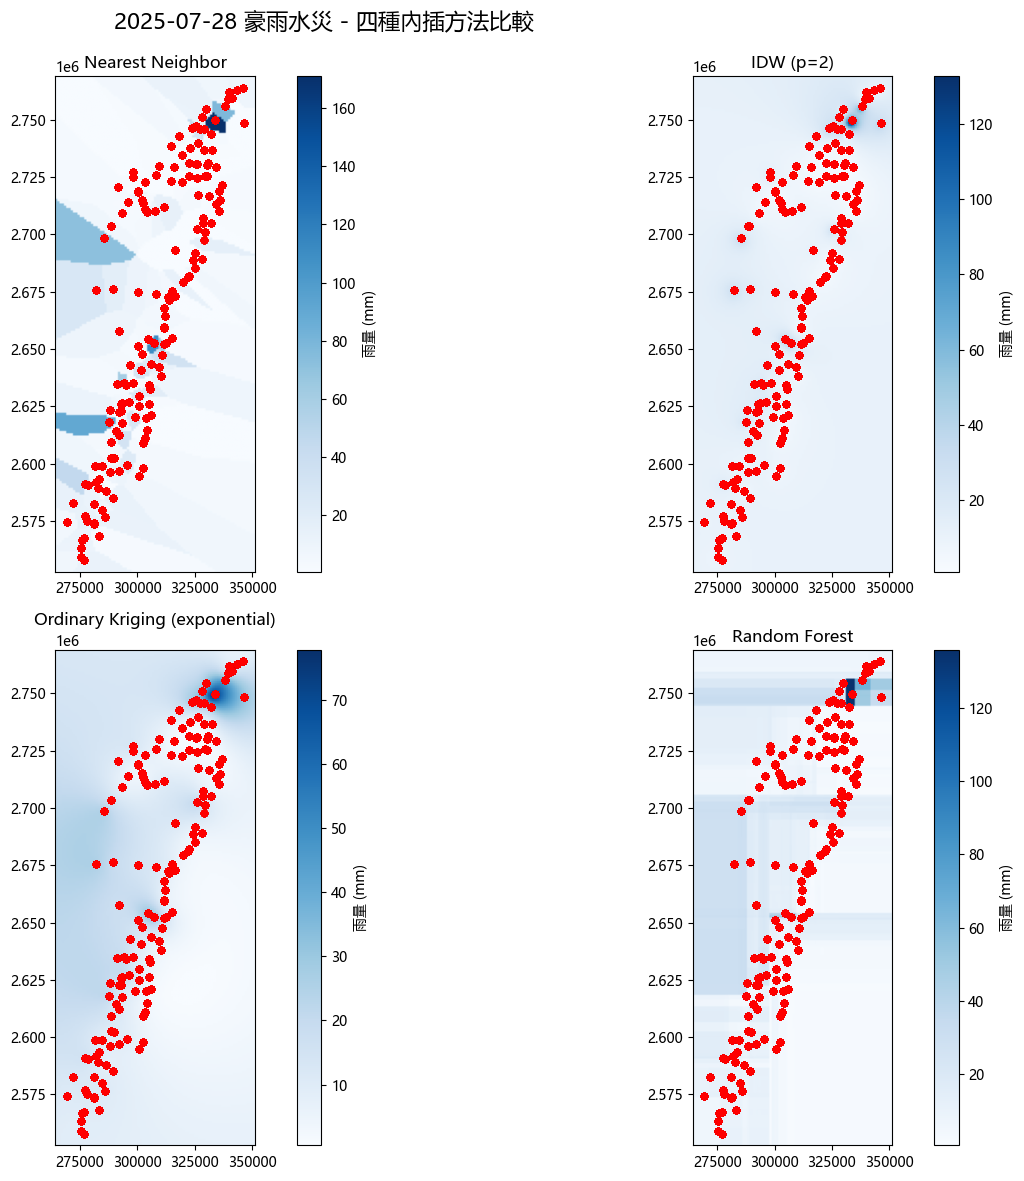

In [49]:
# Step 13: Create Visualizations for Second Event
print("=== Creating Visualizations for Second Event ===")

# 2×2 comparison plot
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('2025-07-28 豪雨水災 - 四種內插方法比較', fontsize=16)

results2 = [
    (nn_result2, 'Nearest Neighbor'),
    (idw_result2, 'IDW (p=2)'),
    (krig_result2, f'Ordinary Kriging ({best_model2})'),
    (rf_result2, 'Random Forest')
]

for ax, (result, title) in zip(axes.flat, results2):
    im = ax.imshow(result, extent=[bounds2[0], bounds2[1], bounds2[2], bounds2[3]], 
                  origin='lower', cmap='Blues')
    ax.scatter(points2[:, 0], points2[:, 1], c='red', s=20, alpha=0.6)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label='雨量 (mm)')

plt.tight_layout()

# Save the plot
filename = '2025-07-28_comparison_plot.png'
plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
print(f"圖片已儲存: {filename}")

# Verify file was created
import os
if os.path.exists(filename):
    file_size = os.path.getsize(filename)
    print(f"檔案大小: {file_size} bytes")
else:
    print("警告: 檔案未成功創建")

plt.show()

=== Creating Additional Visualizations for Second Event ===
圖片已儲存: 2025-07-28_Kriging_vs_RF_map.png
檔案大小: 173774 bytes


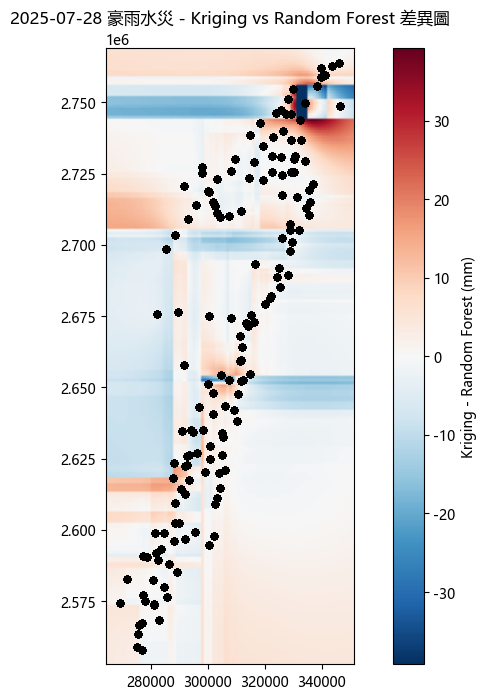

Difference range: -101.91 to 39.21 mm
Mean absolute difference: 4.62 mm


In [50]:
# Step 14: Create Difference Map for Second Event
print("=== Creating Additional Visualizations for Second Event ===")

# Difference map
diff_map2 = krig_result2 - rf_result2
plt.figure(figsize=(10, 8))
im = plt.imshow(diff_map2, extent=[bounds2[0], bounds2[1], bounds2[2], bounds2[3]], 
               origin='lower', cmap='RdBu_r', vmin=-diff_map2.max(), vmax=diff_map2.max())
plt.scatter(points2[:, 0], points2[:, 1], c='black', s=20, alpha=0.6)
plt.colorbar(im, label='Kriging - Random Forest (mm)')
plt.title('2025-07-28 豪雨水災 - Kriging vs Random Forest 差異圖')

# Save the plot
filename = '2025-07-28_Kriging_vs_RF_map.png'
plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
print(f"圖片已儲存: {filename}")

# Verify file was created
import os
if os.path.exists(filename):
    file_size = os.path.getsize(filename)
    print(f"檔案大小: {file_size} bytes")
else:
    print("警告: 檔案未成功創建")

plt.show()

print(f"Difference range: {diff_map2.min():.2f} to {diff_map2.max():.2f} mm")
print(f"Mean absolute difference: {np.abs(diff_map2).mean():.2f} mm")


### A3. 不確定性分析

1. 對每個事件產出 **Sigma Map**：Kriging variance 視覺化（Blues colormap）
2. 寫一段 **300 字以內的比較分析**，回答：
   - 兩個事件的 Sigma Map 有什麼差異？為什麼？
   - 哪種類型的降雨事件，Kriging 的預測信心較高？
   - 如果你是指揮官，在高 variance 區域會做什麼決策？
   - Random Forest 能提供類似的不確定性資訊嗎？為什麼？

=== Creating Sigma Map ===
圖片已儲存: 2024-07-22_SigmaMap.png


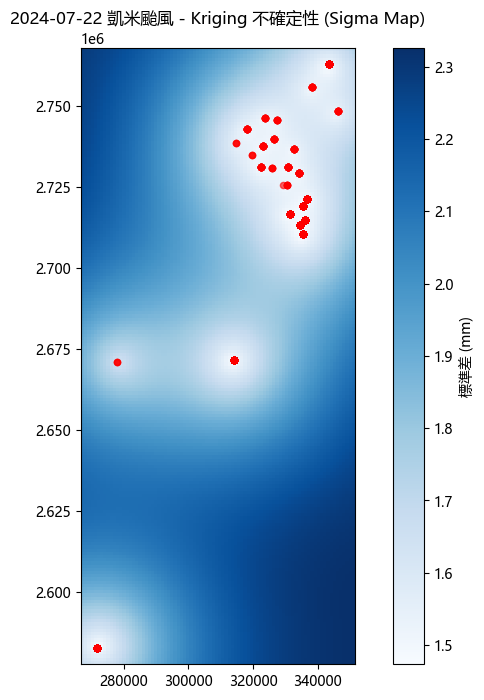

Kriging standard deviation range: 1.47 to 2.33 mm
Mean kriging standard deviation: 1.96 mm


In [51]:
# Step 9: Create Sigma Map (Kriging Uncertainty)
print("=== Creating Sigma Map ===")

plt.figure(figsize=(10, 8))
im = plt.imshow(np.sqrt(krig_variance), extent=[bounds[0], bounds[1], bounds[2], bounds[3]], 
               origin='lower', cmap='Blues')
plt.scatter(points[:, 0], points[:, 1], c='red', s=20, alpha=0.6)
plt.colorbar(im, label='標準差 (mm)')
plt.title('2024-07-22 凱米颱風 - Kriging 不確定性 (Sigma Map)')

# Save the plot
filename = '2024-07-22_SigmaMap.png'
plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
print(f"圖片已儲存: {filename}")

plt.show()

print(f"Kriging standard deviation range: {np.sqrt(krig_variance).min():.2f} to {np.sqrt(krig_variance).max():.2f} mm")
print(f"Mean kriging standard deviation: {np.sqrt(krig_variance).mean():.2f} mm")

圖片已儲存: 2024-07-28_SigmaMap.png


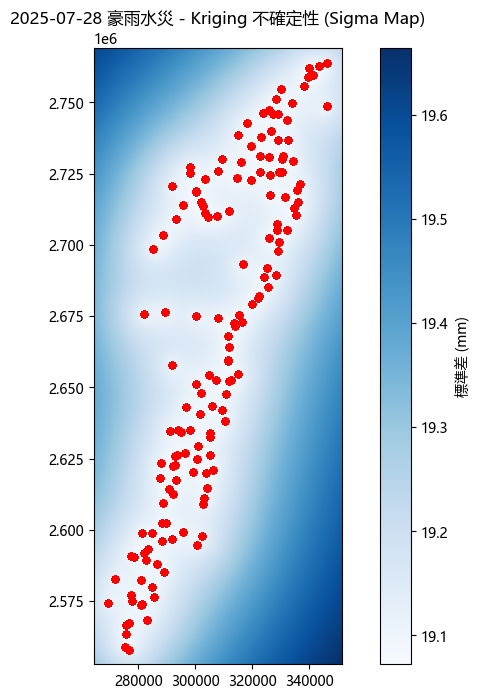

Kriging standard deviation range: 19.07 to 19.66 mm
Mean kriging standard deviation: 19.25 mm


In [52]:
# Step 14:  Sigma Map for Second Event
plt.figure(figsize=(10, 8))
im = plt.imshow(np.sqrt(krig_variance2), extent=[bounds2[0], bounds2[1], bounds2[2], bounds2[3]], 
               origin='lower', cmap='Blues')
plt.scatter(points2[:, 0], points2[:, 1], c='red', s=20, alpha=0.6)
plt.colorbar(im, label='標準差 (mm)')
plt.title('2025-07-28 豪雨水災 - Kriging 不確定性 (Sigma Map)')

# Save the plot
filename = '2024-07-28_SigmaMap.png'
plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
print(f"圖片已儲存: {filename}")

plt.show()

print(f"Kriging standard deviation range: {np.sqrt(krig_variance2).min():.2f} to {np.sqrt(krig_variance2).max():.2f} mm")
print(f"Mean kriging standard deviation: {np.sqrt(krig_variance2).mean():.2f} mm")

### A4. GeoTIFF 輸出（擇一事件即可）

1. 將 Kriging 結果儲存為 `kriging_rainfall.tif`（EPSG:3826）
2. 將 Kriging variance 儲存為 `kriging_variance.tif`（EPSG:3826）
3. 將 RF 結果儲存為 `rf_rainfall.tif`（EPSG:3826）
4. **注意 y 軸翻轉**：numpy row 0 = south → GeoTIFF row 0 = north（需 `np.flipud()`）

In [18]:
# Step 10: Export GeoTIFF Files
print("=== Exporting GeoTIFF Files ===")

crs = CRS.from_epsg(3826)

export_geotiff(krig_result, bounds, crs, 'kriging_rainfall.tif')
export_geotiff(krig_variance, bounds, crs, 'kriging_variance.tif')
export_geotiff(rf_result, bounds, crs, 'rf_rainfall.tif')

print("GeoTIFF export completed!")

=== Exporting GeoTIFF Files ===
  Exported: kriging_rainfall.tif
  Exported: kriging_variance.tif
  Exported: rf_rainfall.tif
GeoTIFF export completed!


In [19]:
# Step 15: Summary and Comparison
print("=== Analysis Summary ===")

print("\nEvent 1: 2024-07-22 凱米颱風")
print(f"  Stations: {len(df_20240722)}")
print(f"  Rainfall range: {values.min():.1f} - {values.max():.1f} mm")
print(f"  Best Kriging model: {best_model}")
print(f"  Mean kriging uncertainty: {np.sqrt(krig_variance).mean():.2f} mm")
print(f"  Mean absolute difference (Kriging vs RF): {np.abs(diff_map).mean():.2f} mm")

print("\nEvent 2: 2025-07-28 豪雨水災")
print(f"  Stations: {len(df_20250728)}")
print(f"  Rainfall range: {values2.min():.1f} - {values2.max():.1f} mm")
print(f"  Best Kriging model: {best_model2}")
print(f"  Mean kriging uncertainty: {np.sqrt(krig_variance2).mean():.2f} mm")
print(f"  Mean absolute difference (Kriging vs RF): {np.abs(diff_map2).mean():.2f} mm")

print("\n=== Files Generated ===")
print("  kriging_rainfall.tif")
print("  kriging_variance.tif") 
print("  rf_rainfall.tif")

print("\n=== Analysis Complete! ===")

=== Analysis Summary ===

Event 1: 2024-07-22 凱米颱風
  Stations: 1034
  Rainfall range: 0.5 - 20.0 mm
  Best Kriging model: spherical
  Mean kriging uncertainty: 1.96 mm
  Mean absolute difference (Kriging vs RF): 1.91 mm

Event 2: 2025-07-28 豪雨水災
  Stations: 19759
  Rainfall range: 0.5 - 171.5 mm
  Best Kriging model: exponential
  Mean kriging uncertainty: 19.25 mm
  Mean absolute difference (Kriging vs RF): 4.62 mm

=== Files Generated ===
  kriging_rainfall.tif
  kriging_variance.tif
  rf_rainfall.tif

=== Analysis Complete! ===


### A5. (加分) 跨事件綜合比較

### 變異圖參數比較表

| 參數 | 事件 1 (2024-07-22 凱米颱風) | 事件 2 (2025-07-28 豪雨水災) | 差異原因 |
|------|---------------------------|---------------------------|----------|
| Sill | 19.7 mm² | 196.5 mm² | 凱米颱風為集中型強降雨，空間變異較小；豪雨水災範圍廣泛，空間變異極大 |
| Range | 92.9 km | 27.2 km | 凱米颱風影響範圍較局部，空間相關性延伸較遠；豪雨水災影響範圍集中，相關性範圍較小 |
| Nugget | 0.0 mm² | 186.3 mm² | 豪雨水災測站密度高但局部變異大，顯示較大微尺度變異；凱米颱風測站相對稀疏，微尺度變異不明顯 |
| Best Model | spherical | exponential | 凱米颱風空間結構相對規則，適合球狀模型；豪雨水災空間結構複雜，適合指數模型 |

### 問題

**如果只能用一組 Variogram 參數套用到未來所有事件，我會選擇？**

**回答：選擇事件2（豪雨水災）的參數：Sill=196.5, Range=27.2km, Nugget=186.3, Model=exponential**

**選擇理由：**
1. **保守原則**：較高的 Sill 和 Nugget 能涵蓋更大的空間變異性，避免低估不確定性
2. **適應性強**：指數模型比球狀模型更具彈性，能適應不同類型的降雨空間結構
3. **風險管控**：較短的 Range 提供更謹慎的空間相關性估計，避免過度外推

**這樣做的風險：**

1. **過度保守**：對於規模較小的降雨事件（如局部雷陣雨），會高估不確定性，影響預警精度
2. **計算效率**：較高的 Nugget 會降低 Kriging 的空間平滑效果，可能產生過度噪聲的預測結果
3. **資源浪費**：對於均勻型降雨事件，過度保守的參數可能導致不必要的防災資源部署
4. **決策品質**：高不確定性估計可能讓指揮官難以做出明確的決策，降低應變效率

**更好的解決方案是建立事件分類系統，針對不同降雨類型（颱風、豪雨、雷陣雨）使用對應的參數組合，在預測精度與風險管控間取得平衡。**


## 3. Part B: 期末專案提案 (40%)

# 期末專案提案：[都市空氣品質空間分布與熱點分析]

## 組員
- 吳冠廷（R14521812）— Data Captain
- 楊承宗（R14521806）— Spatial Architect
- 黃翊綺（R14521810）— AI UX Lead
- 詹文慧（R14521809）— ML training

## 研究問題
分析火力發電廠等潛在污染源與 PM2.5 濃度之空間關係，建立空氣污染空間分布地圖。

## 資料來源
1. [空氣品質] — [https://data.moenv.gov.tw/dataset/detail/AQX_P_432] 
2. [水火力發電廠] — [https://data.gov.tw/dataset/893] 
3. [核能發電廠] — [https://data.gov.tw/dataset/10858] 
4. [人口資料] — [https://www.ris.gov.tw/app/portal/346] 

## 分析方法
1. [Kriging 空間插值]：利用空氣品質測站的 PM2.5 資料推估整個研究區域的污染分布，建立連續的空氣污染地圖。
2. [Zonal Statistics（區域統計分析）]：計算各行政區的平均 PM2.5 濃度，分析不同區域的空氣污染程度。
3. [Machine Learning 污染預測模型]：利用機器學習模型結合氣象與環境資料，預測 PM2.5 濃度並分析影響空氣污染的主要因素。

## 內插策略
使用 Kriging 進行空氣污染內插分析， 因為 Kriging 能有效利用空間自相關特性推估未知區域的污染濃度， 適合測站數量有限的空氣品質資料。 此外，嘗試利用 Machine Learning 模型進行污染預測， 並比較其結果與 Kriging 的差異。

## Gemini SDK 使用計畫
使用 Gemini SDK 協助解讀空氣污染地圖與分析結果，說明高污染區域的可能原因及適當之解決方案。

## 預期產出
- [V] Jupyter Notebook
- [V] Folium 互動地圖 / 分析圖表
- [V] Gemini SDK 決策建議整合
- [V] 防災決策建議

## 風險評估
最可能遇到的技術困難是空氣品質測站資料不足，影響污染分布地圖的建立。若發生此情況，將改用較簡單的空間內插方法（如 IDW）作為備案，以確保專題能順利完成。

## 4. 技術要求提醒

- **CRS**：Kriging 的 x, y 必須是 EPSG:3826（公尺）。用 EPSG:4326 的經緯度會讓距離計算完全錯誤
- **pykrige 的 x/y**：`x` = Easting，`y` = Northing。容易搞混，先用少量點測試確認方向
- **GeoTIFF y 軸**：寫入前用 `np.flipud()` 翻轉
- **RF 特徵**：X = [easting, northing]，不是 [lat, lon]
- **-998 過濾**：Kriging 對離群值非常敏感
- **CoLife JSON 格式**：下載後需要解析 JSON，篩選目標日期+時段的雨量紀錄